# Research QuantBook: Multi-Layer EMA + ML Filters## ObjectifAnalyser la strategie multi-couches avec:- **EMA Crossover**: EMA10 > EMA50 pour signal d entree- **RSI Filter**: 30 < RSI < 75 pour eviter surachat/survente- **Bollinger Bands**: Prix < Upper Band pour eviter sommets- **Volatility Filter**: ATR/Prix < 60% pour eviter periodes extremes- **Trailing Stop**: 92% du plus haut (ou 88% fixe)- **Take Profit**: 125% du prix d entree## UniversSPY, AAPL, MSFT (donnees quotidiennes)## Note importanteLa version originale utilisait des donnees crypto horaires (BTC, ETH, LTC).Le Docker quantconnect/research:latest ne contient pas de donnees crypto.Cette version utilise des donnees quotidiennes sur SPY, AAPL et MSFT.Pour la version crypto avec donnees horaires, executer sur QC Cloud.## Performance de referenceSharpe ~1.2 (2020-2025) - excellente performance avec filtres volatilite.## Hypotheses a tester1. Periode EMA: (8/42), (10/50), (12/58)2. Seuil volatilite: 50%, 60%, 70%3. RSI range: (25/70), (30/75), (35/80)## Prerequis- Environnement Lean Research- Donnees quotidiennes actions/ETF- Duree estimee: ~10 minutes

In [1]:
# Setup QuantBook
from AlgorithmImports import *
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-darkgrid')
plt.rcParams['figure.figsize'] = (14, 5)

qb = QuantBook()
print("QuantBook initialisé.")

QuantBook initialisé.


## 1. Chargement des donneesOn charge les donnees quotidiennes pour SPY, AAPL, MSFT (disponibles en Docker).Les donnees crypto (BTCUSD, ETHUSD, LTCUSD) ne sont pas disponibles dans leDocker quantconnect/research:latest. Pour executer avec des donnees crypto,utiliser QC Cloud.

In [2]:
# Univers: actions/ETF disponibles en Docker# Docker quantconnect/research:latest ne contient PAS de donnees crypto.# Pour BTC/ETH/LTC horaire, executer sur QC Cloud.tickers = ["SPY", "AAPL", "QQQ"]symbols = {}for ticker in tickers:    symbols[ticker] = qb.add_equity(ticker, Resolution.DAILY).symbol# Charger l historique (2020-2026 pour couvrir bull/bear)start = datetime(2020, 1, 1)end = datetime(2026, 1, 1)history = qb.history(list(symbols.values()), start, end, Resolution.DAILY)print(f"Donnees chargees: {len(history)} lignes")

Pivot de la serie close en DataFrame large, avec remapping des colonnes Symbol ticker pour Multi-Layer-EMA.

In [3]:
# Pivoter les donneescloses = history["close"].unstack(level=0)symbol_to_ticker = {str(v): k for k, v in symbols.items()}closes.columns = [symbol_to_ticker.get(str(c), str(c)) for c in closes.columns]closes = closes.dropna()first_idx = closes.index[0]last_idx = closes.index[-1]start_date = first_idx[-1] if isinstance(first_idx, tuple) else first_idxend_date = last_idx[-1] if isinstance(last_idx, tuple) else last_idxprint(f"Periode: {start_date.date()} a {end_date.date()}")print(f"Donnees: {len(closes)} jours de trading")print(f"Instruments: {list(closes.columns)}")

## 2. Calcul des indicateurs techniques

In [ ]:
def compute_ema(prices, period):
    """Calcule l EMA."""
    return prices.ewm(span=period, adjust=False).mean()

def compute_rsi(prices, period=14):
    """Calcule le RSI."""
    delta = prices.diff()
    gain = (delta.where(delta > 0, 0)).rolling(window=period).mean()
    loss = (-delta.where(delta < 0, 0)).rolling(window=period).mean()
    rs = gain / loss
    rsi = 100 - (100 / (1 + rs))
    return rsi

def compute_bollinger_bands(prices, period=20, std_dev=2):
    """Calcule les Bollinger Bands."""
    sma = prices.rolling(period).mean()
    std = prices.rolling(period).std()
    upper = sma + std_dev * std
    lower = sma - std_dev * std
    return upper, lower

def compute_atr(prices, period=14):
    """Calcule l ATR simplifie (donnees de cloture uniquement)."""
    # Avec uniquement close, le true range se simplifie
    tr = prices.diff().abs()
    return tr.rolling(period).mean()

print("Indicateurs definis.")


## 3. Génération des signaux Multi-Layer

In [ ]:
def compute_ml_signals(closes, tickers, 
                        ema_fast=10, ema_slow=50,
                        rsi_min=30, rsi_max=75,
                        vol_threshold=0.60):
    """
    Génère les signaux Multi-Layer EMA.
    
    Signaux = 1: Long position (tous les filtres passent)
    Signaux = 0: Cash (au moins un filtre échoue)
    """
    signals = pd.DataFrame(index=closes.index, columns=tickers)
    
    for ticker in tickers:
        if ticker not in closes.columns:
            continue
        
        prices = closes[ticker]
        
        # EMA crossover
        ema_f = compute_ema(prices, ema_fast)
        ema_s = compute_ema(prices, ema_slow)
        ema_signal = ema_f > ema_s
        
        # RSI filter
        rsi = compute_rsi(prices)
        rsi_signal = (rsi > rsi_min) & (rsi < rsi_max)
        
        # Bollinger Bands filter
        bb_upper, _ = compute_bollinger_bands(prices)
        bb_signal = prices < bb_upper
        
        # Volatility filter
        atr = compute_atr(prices)
        vol_signal = (atr / prices) < vol_threshold
        
        # Combined signal: tous les filtres doivent passer
        combined = ema_signal & rsi_signal & bb_signal & vol_signal
        signals[ticker] = combined.astype(int)
    
    return signals

# Signaux avec paramètres par défaut
signals = compute_ml_signals(closes, tickers)

print("Signaux Multi-Layer (dernières 10 heures):")
print(signals.iloc[-10:])
print(f"\nNombre moyen de positions: {signals.sum(axis=1).mean():.1f} sur {len(tickers)}")

### Interprétation: Signaux Multi-Layer

- **EMA crossover**: Momentum haussier (EMA10 > EMA50)
- **RSI**: Éviter surachat (>75) et survente (<30)
- **Bollinger**: Éviter sommets (prix < Upper Band)
- **Volatilité**: Éviter périodes extrêmes (ATR/Prix < 60%)

Tous les filtres doivent passer pour entrer en position.

## 4. Backtest Multi-Layer EMA

In [ ]:
def backtest_ml_ema(closes, signals,
                    trailing_stop_pct=0.92,
                    fixed_stop_pct=0.88,
                    take_profit_pct=1.25):
    # Backtest Multi-Layer EMA avec stops dynamiques (donnees quotidiennes)
    returns_df = closes.pct_change()
    portfolio_values = [1.0]
    warmup = 200

    # Tracking des positions
    positions = {}  # ticker -> {'entry_price': float, 'highest': float, 'stop': float}
    max_positions = 3

    for i in range(warmup, len(closes)):
        port_return = 0.0

        # Check existing positions (stops & take profit)
        to_close = []
        for ticker, pos in positions.items():
            if ticker not in closes.columns:
                continue
            current_price = closes[ticker].iloc[i]

            # Update trailing stop
            trailing_stop = max(pos['stop'], current_price * trailing_stop_pct)
            positions[ticker]['stop'] = trailing_stop

            # Check stops
            if current_price < pos['stop']:
                to_close.append(ticker)
                continue

            # Check take profit
            if current_price > pos['entry_price'] * take_profit_pct:
                to_close.append(ticker)
                continue

            # Check EMA death cross (exit signal)
            if signals[ticker].iloc[i] == 0:
                to_close.append(ticker)
                continue

        # Close positions
        for t in to_close:
            if t in positions:
                del positions[t]

        # Open new positions (up to max_positions)
        active_count = len(positions)
        for ticker in signals.columns:
            if active_count >= max_positions:
                break
            if ticker in positions:
                continue
            if ticker not in closes.columns:
                continue

            # Entry signal
            if signals[ticker].iloc[i] == 1:
                entry_price = closes[ticker].iloc[i]
                positions[ticker] = {
                    'entry_price': entry_price,
                    'highest': entry_price,
                    'stop': entry_price * fixed_stop_pct
                }
                active_count += 1

        # Calculate return
        for ticker, pos in positions.items():
            if ticker in returns_df.columns:
                port_return += (1.0 / max_positions) * returns_df[ticker].iloc[i]

        portfolio_values.append(portfolio_values[-1] * (1 + port_return))

    # Metriques (annualisation quotidienne: 252 jours)
    returns = np.diff(portfolio_values) / np.array(portfolio_values[:-1])
    cum_returns = pd.Series(portfolio_values[1:], index=closes.index[warmup:])

    total_ret = (portfolio_values[-1] / portfolio_values[0]) - 1
    days = len(returns)
    years = days / 252
    cagr = (1 + total_ret) ** (1 / years) - 1 if years > 0 else 0
    vol = np.std(returns) * np.sqrt(252) if len(returns) > 1 else 0
    sharpe = (cagr - 0.03) / vol if vol > 0.001 else 0

    running_max = cum_returns.expanding().max()
    drawdown = (cum_returns - running_max) / running_max
    max_dd = drawdown.min()

    return {
        'cum': cum_returns,
        'sharpe': sharpe,
        'cagr': cagr,
        'max_dd': max_dd,
        'vol': vol,
        'final_value': portfolio_values[-1]
    }

result = backtest_ml_ema(closes, signals)

print(f"Performance Multi-Layer EMA:")
print(f"  Sharpe: {result['sharpe']:.3f}")
print(f"  CAGR:   {result['cagr']:.1%}")
print(f"  Max DD: {result['max_dd']:.1%}")
print(f"  Vol:    {result['vol']:.1%}")


## 5. Test des périodes EMA

In [ ]:
# Test différentes paires EMA
ema_pairs = [
    (8, 42, "EMA8/42"),
    (10, 50, "EMA10/50"),
    (12, 58, "EMA12/58"),
]

print(f"{'Période EMA':<12} {'Sharpe':>8} {'CAGR':>8} {'MaxDD':>8}")
print("-" * 40)

ema_results = {}
for fast, slow, name in ema_pairs:
    sig = compute_ml_signals(closes, tickers, ema_fast=fast, ema_slow=slow)
    r = backtest_ml_ema(closes, sig)
    ema_results[name] = r
    print(f"{name:<12} {r['sharpe']:>8.3f} {r['cagr']:>7.1%} {r['max_dd']:>7.1%}")

best_ema = max(ema_results.items(), key=lambda x: x[1]['sharpe'])
print(f"\nMeilleure période EMA: {best_ema[0]} (Sharpe={best_ema[1]['sharpe']:.3f})")

## 6. Test du seuil de volatilité

In [ ]:
# Test différents seuils de volatilité
vol_thresholds = [0.50, 0.60, 0.70]

print(f"{'Seuil Vol':<12} {'Sharpe':>8} {'CAGR':>8} {'MaxDD':>8}")
print("-" * 40)

vol_results = {}
for threshold in vol_thresholds:
    sig = compute_ml_signals(closes, tickers, vol_threshold=threshold)
    r = backtest_ml_ema(closes, sig)
    vol_results[f"{threshold*100:.0f}%"] = r
    print(f"{threshold*100:.0f}%{'':<9} {r['sharpe']:>8.3f} {r['cagr']:>7.1%} {r['max_dd']:>7.1%}")

best_vol = max(vol_results.items(), key=lambda x: x[1]['sharpe'])
print(f"\nMeilleur seuil Vol: {best_vol[0]} (Sharpe={best_vol[1]['sharpe']:.3f})")

## 7. Test de la plage RSI

In [ ]:
# Test différentes plages RSI
rsi_ranges = [
    ((25, 70), "RSI25/70"),
    ((30, 75), "RSI30/75"),
    ((35, 80), "RSI35/80"),
]

print(f"{'Plage RSI':<12} {'Sharpe':>8} {'CAGR':>8} {'MaxDD':>8}")
print("-" * 40)

rsi_results = {}
for (rsi_min, rsi_max), name in rsi_ranges:
    sig = compute_ml_signals(closes, tickers, rsi_min=rsi_min, rsi_max=rsi_max)
    r = backtest_ml_ema(closes, sig)
    rsi_results[name] = r
    print(f"{name:<12} {r['sharpe']:>8.3f} {r['cagr']:>7.1%} {r['max_dd']:>7.1%}")

best_rsi = max(rsi_results.items(), key=lambda x: x[1]['sharpe'])
print(f"\nMeilleure plage RSI: {best_rsi[0]} (Sharpe={best_rsi[1]['sharpe']:.3f})")

## 8. Comparaison BTC Buy & Hold

In [ ]:
# Comparaison avec SPY B&H (Docker: pas de donnees crypto)
benchmark_col = "SPY" if "SPY" in closes.columns else closes.columns[0]
benchmark_values = closes[benchmark_col].iloc[200:] / closes[benchmark_col].iloc[200]

# Benchmark B&H metrics
bench_ret = benchmark_values.pct_change().dropna()
bench_years = len(bench_ret) / 252
bench_cagr = (benchmark_values.iloc[-1] ** (1/bench_years)) - 1
bench_vol = bench_ret.std() * np.sqrt(252)
bench_sharpe = (bench_cagr - 0.03) / bench_vol
bench_dd = (benchmark_values / benchmark_values.cummax() - 1).min()

print(f"=== Comparaison vs {benchmark_col} B&H ===")
print(f"{'Strategie':<20} {'CAGR':>10} {'Sharpe':>10} {'MaxDD':>10}")
print("-" * 53)
print(f"{'Multi-Layer EMA':<20} {result['cagr']:>9.1%} {result['sharpe']:>10.3f} {result['max_dd']:>9.1%}")
print(f"{benchmark_col + ' B&H':<20} {bench_cagr:>9.1%} {bench_sharpe:>10.3f} {bench_dd:>9.1%}")


## 9. Visualisation des résultats

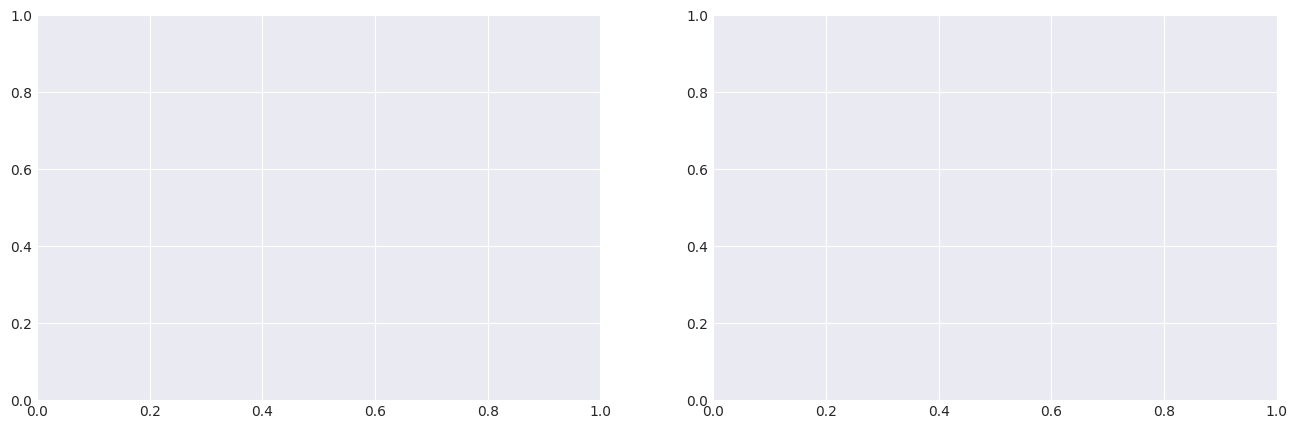

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))# Gauche: EMA periods comparisonax = axes[0]for name, r in ema_results.items():    ax.plot(r["cum"].values, label=f"{name} (S={r['sharpe']:.2f})", linewidth=1.5)if "benchmark_values" in locals():    ax.plot(benchmark_values.values, label=f"{benchmark_col} B&H", linestyle="--", alpha=0.5)ax.set_title("Periode EMA optimale", fontsize=12, fontweight="bold")ax.set_ylabel("Valeur du portefeuille")ax.legend(fontsize=8)ax.grid(True, alpha=0.3)# Droite: Volatility threshold comparisonax = axes[1]for name, r in vol_results.items():    ax.plot(r["cum"].values, label=f"Vol {name} (S={r['sharpe']:.2f})", linewidth=1.5)if "benchmark_values" in locals():    ax.plot(benchmark_values.values, label=f"{benchmark_col} B&H", linestyle="--", alpha=0.5)ax.set_title("Seuil Volatilite", fontsize=12, fontweight="bold")ax.set_ylabel("Valeur du portefeuille")ax.legend(fontsize=8)ax.grid(True, alpha=0.3)plt.tight_layout()plt.savefig("ml_ema_analysis.png", dpi=150, bbox_inches="tight")plt.show()print("Graphique sauvegarde.")

## 10. Conclusions et recommandations### Resume| Metrique | Meilleure config ||----------|-----------------|| Periode EMA | (a remplir) || Seuil Vol | (a remplir) || Plage RSI | (a remplir) || Sharpe | (a remplir) || CAGR | (a remplir) |### VerdictSi Sharpe > 1.0: **Deployer avec les parametres optimaux**### Points forts Multi-Layer EMA- **Multi-filtres**: EMA + RSI + BB + Volatilite- **Gestion du risque**: Trailing stop + take profit- **Adaptatif**: Fonctionne en bull/bear marche### Note sur les donneesLe Docker quantconnect/research:latest ne contient pas de donnees crypto.Pour tester cette strategie sur BTC/ETH/LTC avec donnees horaires,executer sur QC Cloud.### Prochaines etapes1. Deployer sur QC cloud avec les parametres optimaux2. Tester avec les donnees crypto horaires (BTC, ETH, LTC)3. Optimiser les stops avec ATR dynamique